In [1]:
# расчет и визуализация
# напряженности магнитного поля,
# создаваемого постоянным током
# конечной длины

# ячейка № 1
# подключение библиотеки numpy
import numpy as np

# подключение библиотеки
import matplotlib.pyplot as plt

In [2]:
# Ячейка № 2

# задание функции, возвращающей
# вектор напряженности магнитного поля,
# создаваемого элементарным линейным током,
# вычисляемый в соответствие с (5.12)
def Strange_EС(r, R, dL):
    # r - радиус-вектор элементарного тока
    # R0 - радиус-вектор точки наблюдения,
    # в которой рассчитывается напряженность магнитного поля
    # задание координат вектора элементарных токов

    # вычисление радиуса-вектора точки наблюдения
    Tmp = R - r

    # вычисление в соответствие с (5.12)
    # вектора напряженности магнитного поля,
    # создаваемого элементарным линейным током
    s = np.cross(dL, Tmp) / np.sqrt(np.dot(Tmp, Tmp)) ** 3

    return s

In [3]:
# Ячейка № 3

# задание функция, возвращающей
# значения вектора-потенциала
# магнитного поля, создаваемого
# элементарным линейным током,
# вычисляемым в соответствие с ()
def A_EС(r, R, dL):
    # r - радиус-вектор элементарного тока
    # R0 - радиус-вектор точки наблюдения,
    # в которой рассчитывается напряженность магнитного поля
    # задание координат вектора элементарных токов
    Tmp = R - r
    s = dL / np.sqrt(np.dot(Tmp, Tmp))
    return s

In [ ]:
# Ячейка № 4

# задание числа узлов сетки
# по соответствующим координатным осям
Nx = 17
Ny = 17

# задание координат левого и
# правого концов провода
z_min = -30.1
z_max = 30

# задание числа элементарных токов
Nc = 200

# задание аппликат радиусов-векторов
# элементарных токов
z = np.linspace(z_min, z_max, Nc)

# вычисление шага изменения
# аппликаты радиуса-вектора
delta_z = z[1] - z[0]

# определение числа элементарных токов
Nc = len(z)

# задание значений координат узлов
# используемой координатной сетки
X = np.linspace(-3.1, 3, Nx)
Y = np.linspace(-3.1, 3, Ny)
Z = 29

# задание координат вектора dL
dL = np.array([0, 0, delta_z])

# инициализация массивов,
# используемых для размещения
# значений проекций напряженности
# магнитного поля на соответствующие
# координатные оси
bx = np.zeros([Nx, Ny])
by = np.zeros([Nx, Ny])
bz = np.zeros([Nx, Ny])

# вычисление значений
# проекций напряженности
# магнитного поля на соответствующие
# координатные оси
X1, Y1 = np.meshgrid(X, Y)
for i in range(Nx):
    for j in range(Ny):
        s = np.array([0, 0, 0])
        for k in range(Nc):
            R = np.array([X1[i, j], Y1[i, j], Z])
            r = np.array([0, 0, z[k]])
            s = s + Strange_EС(r, R, dL)
        bx[i, j] = s[0]
        by[i, j] = s[1]
        bz[i, j] = s[2]

# вычисление модуля магнитного поля
mp = np.zeros([Nx, Ny])
for i in range(Nx):
    for j in range(Ny):
        mp[i, j] = np.sqrt(bx[i, j] ** 2 + by[i, j] ** 2 + bz[i, j] ** 2)

# вычисление координат единичных векторов,
# сонаправленных с векторами
# напряженности магнитного поля
bx1 = np.zeros([Nx, Ny])
by1 = np.zeros([Nx, Ny])
for i in range(Nx):
    for j in range(Ny):
        bx1[i, j] = bx[i, j] / mp[i, j]
        by1[i, j] = by[i, j] / mp[i, j]

# инициализация массивов,
# используемых для размещения
# значений проекций вектора-потенциала
# магнитного поля на соответствующие
# координатные оси
ax = np.zeros([Nx, Ny])
ay = np.zeros([Nx, Ny])
az = np.zeros([Nx, Ny])

# вычисление значений
# проекций вектора-потенциала
# магнитного поля на соответствующие
# координатные оси и его модуля
A = np.zeros([Nx, Ny])
for i in range(Nx):
    for j in range(Ny):
        s = np.array([0, 0, 0])
        for k in range(Nc):
            R = np.array([X1[i, j], Y1[i, j], Z])
            r = np.array([0, 0, z[k]])
            s = s + A_EС(r, R, dL)
        ax = s[0]
        ay = s[1]
        az = s[2]
        A[i, j] = np.sqrt(ax**2 + ay**2 + az**2)


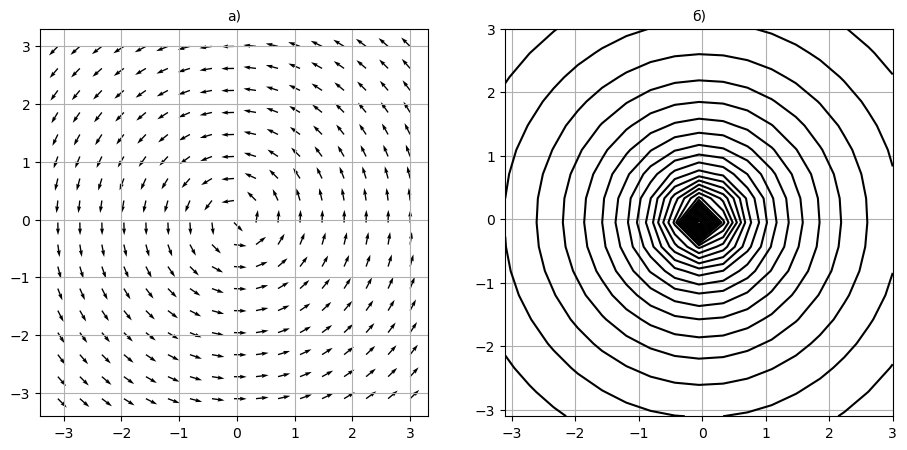

--------------------------------------------


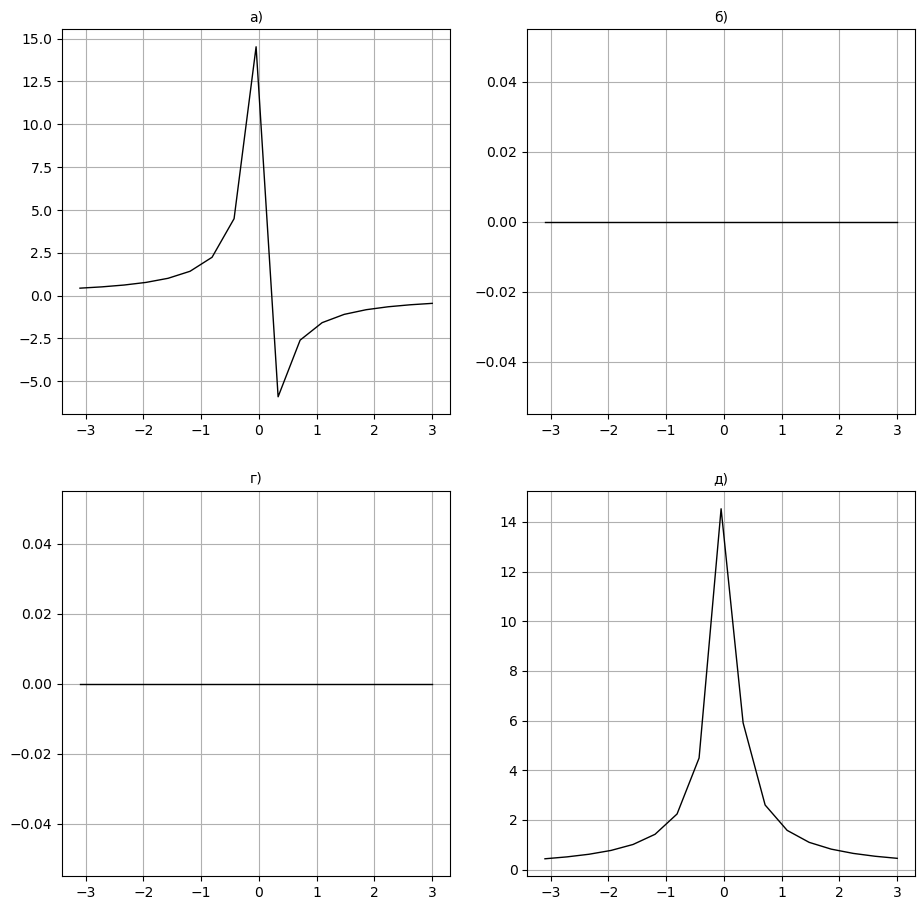

In [5]:
# Ячейка № 5

fig = plt.figure(figsize=(11, 11))

# визуализация поля нормированных векторов,
# сонаправленных с векторами напряженности
# магнитного поля в плоскости Z=0
ax = fig.add_subplot(1, 2, 1)
q = ax.quiver(X1, Y1, bx1, by1)
ax.set_aspect("equal", "box")
ax.set_title("а)", fontsize=10)
ax.grid(True)

# визуализация карты эквипотенциалей
# вектора потенциала магнитного поля
ax = fig.add_subplot(1, 2, 2)
CS = ax.contour(X1, Y1, A, levels=33, colors="black")
ax.set_title("б)", fontsize=10)
ax.set_aspect("equal", "box")
ax.grid(True)
plt.show()

# вычисление модуля
# напряженности магнитного поля
bx2 = np.zeros(Ny)
by2 = np.zeros(Ny)
bz2 = np.zeros(Ny)
b2 = np.zeros(Ny)
for j in range(Ny):
    s = np.array([0, 0, 0])
    for k in range(Nc):
        R = np.array([0, Y[j], Z])
        r = np.array([0, 0, z[k]])
        s = s + Strange_EС(r, R, dL)
    bx2[j] = s[0]
    by2[j] = s[1]
    bz2[j] = s[2]
    b2[j] = np.sqrt(bx2[j] ** 2 + by2[j] ** 2 + bz2[j] ** 2)

print("--------------------------------------------")

fig = plt.figure(figsize=(11, 11))

# визуализация зависимости Bx=Bx(0,y,0)
ax = fig.add_subplot(2, 2, 1)
ax.plot(Y, bx2, "-k", lw=1)
ax.set_title("а)", fontsize=10)
ax.grid(True)

# визуализация зависимости By=By(0,y,0)
ax = fig.add_subplot(222)
ax.plot(Y, by2, "-k", lw=1)
ax.set_title("б)", fontsize=10)
ax.grid(True)

# визуализация зависимости Bz=Bz(0,y,0)
ax = fig.add_subplot(223)
ax.plot(Y, bz2, "-k", lw=1)
ax.set_title("г)", fontsize=10)
ax.grid(True)

ax = fig.add_subplot(224)
ax.plot(Y, b2, "-k", lw=1)
ax.set_title("д)", fontsize=10)
ax.grid(True)

plt.show()